# Problem 2 - Semana 2

## Agenda
- Problem Description
- Problem Implementation
- Alternative Problems
- Wrap-Up

## Problem Description
- <b>Consider a grid of N buses to which generators and loads are connected, and discover a grid loss function based on M per-bus power injection readings and the corresponding M total grid loss measurements.<b>

    _______________________________________________________________________________________________________________________

- <b>Considered "Kite" 5 Bus Network<b>

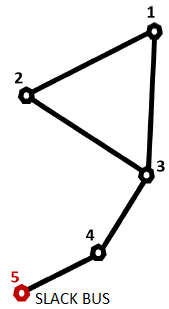

- <b>Implementation (diagram):<b>

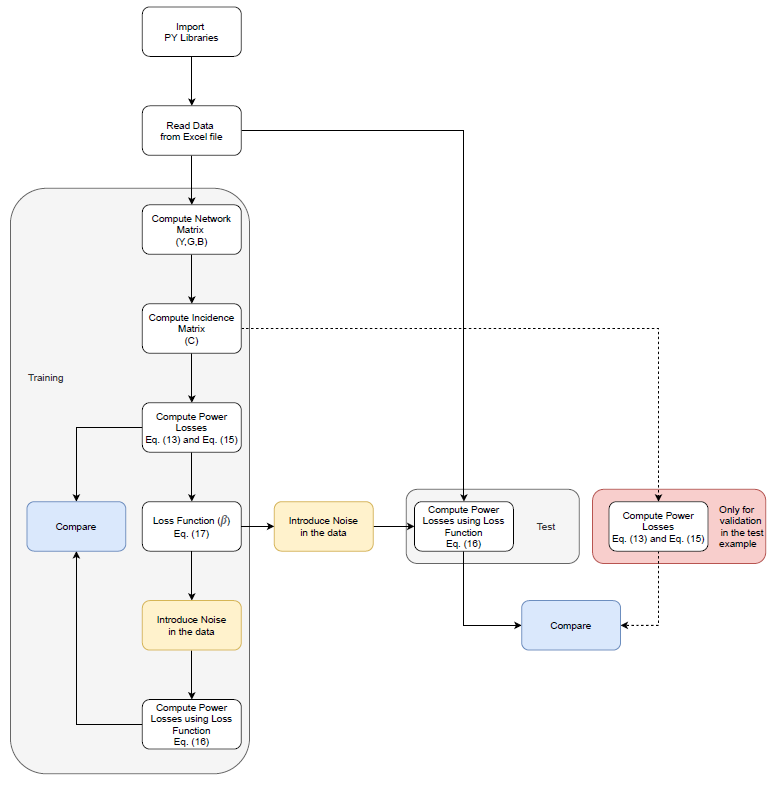

<b>Import Python Libraries

In [38]:
import pandas as pd
import numpy as np
from numpy import linalg as LA 
import matplotlib.pyplot as plt
from numpy.linalg import inv, pinv # linear algebra

# Set numpy to always print a maximum of 3 decimal places

np.set_printoptions(precision=4, suppress=True)

# Parameters

noiseFactor=0.0025     #noise
networkFactor=100      #to change the characteristics of the network (Y)
PtestFactor=3          #to obtain losses similar to the training data;

<b>Import data (From Excel file)

In [39]:
Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Info', header=None))
# Information about the slack bus 
SlackBus=Info[0,1]
print ("Slack Bus: ", SlackBus,"\n") # Barramento de referência

# Network Information - impedâncias das linhas
Net_Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Y_Data'))
print ("Lines information (Admitances)\n", Net_Info, "\n")

#Power Information (train)
Power_Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Load(t,Bus)'))
Power_Info = np.delete(Power_Info,[0],1)
print ("Power consumption information (time, Bus) - (Train)\n", Power_Info, "\n")

#Power Information (test)
Power_Test = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Test_Load(t,Bus)'))
Power_Test = np.delete(Power_Test,[0],1)
print ("Power consumption information (time, Bus) - (Test)\n", Power_Test)

time=Power_Info.shape[0]
Ptrain=Power_Info
Ptest=Power_Test *PtestFactor

Slack Bus:  5 

Lines information (Admitances)
 [[1 2 '0,01-0,1i']
 [1 3 '0,02-0,2i']
 [2 3 '0,03-0,2i']
 [3 4 '0,03-0,2i']
 [4 5 '0,02-0,2i']] 

Power consumption information (time, Bus) - (Train)
 [[0.332 0.064 0.084 0.12 ]
 [0.236 0.164 0.276 0.064]
 [0.224 0.708 1.572 0.072]
 [0.36  3.44  1.188 0.18 ]
 [1.332 2.176 0.484 1.464]
 [1.516 3.02  0.316 0.624]
 [0.92  0.916 0.404 2.772]
 [0.752 0.64  0.396 1.464]
 [1.828 0.684 0.576 0.576]
 [3.568 0.564 0.828 0.428]
 [0.78  0.356 0.728 0.348]
 [0.856 0.22  0.308 0.12 ]
 [0.684 0.528 0.256 0.44 ]] 

Power consumption information (time, Bus) - (Test)
 [[0.18  0.06  0.188 0.132]
 [0.1   0.06  0.992 0.132]
 [0.388 0.1   1.576 0.132]
 [0.28  0.196 0.08  1.94 ]
 [0.5   0.184 0.064 0.572]
 [1.16  0.108 0.064 0.188]
 [1.036 0.06  0.068 0.08 ]
 [1.036 0.064 0.112 0.064]
 [1.768 0.064 0.2   0.068]
 [0.804 0.092 0.184 0.064]
 [0.824 0.196 0.088 0.096]
 [0.52  0.188 0.064 0.196]
 [0.184 0.104 0.068 0.192]]


<b>Admittance Matrix(Y); Conductance Matrix(G); Susceptance Matrix(B)

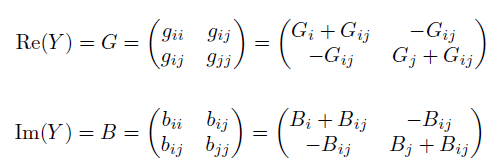

In [40]:
# Determine the number of Bus
nBus=max(np.max(Net_Info[:,0]),np.max(Net_Info[:,1]))

# Create the variable number of lines and the admitance matrix (Y)
nLines=Net_Info.shape[0]

Y=np.zeros((nBus,nBus), dtype=complex) # devido a estarmos a usar AC

#Complete the Y matrix nad update the number of lines
for i in range (Net_Info.shape[0]):
    y_aux=Net_Info[i,2].replace(",",".")
    y_aux=y_aux.replace("i","j")
    Y[Net_Info[i,0]-1,Net_Info[i,0]-1]=Y[Net_Info[i,0]-1,Net_Info[i,0]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,1]-1]=Y[Net_Info[i,1]-1,Net_Info[i,1]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,0]-1,Net_Info[i,1]-1]=Y[Net_Info[i,0]-1,Net_Info[i,1]-1]-complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,0]-1]=Y[Net_Info[i,1]-1,Net_Info[i,0]-1]-complex(y_aux)*networkFactor

            
# Remove the slack bus from the admitance matrix            
Yl=np.delete(Y, np.s_[SlackBus-1], axis=0)
Yl=np.delete(Yl, np.s_[SlackBus-1], axis=1)

# Conductance Matrix
G=Yl.real

# Susceptance Matrix
B=Yl.imag 
print("The admitance matrix Y is:\n", Y, "\n")
print("The conductance matrix G is\n", G, "\n")
print("The susceptance matrix B is\n",B, "\n")


The admitance matrix Y is:
 [[ 3.-30.j -1.+10.j -2.+20.j  0. +0.j  0. +0.j]
 [-1.+10.j  4.-30.j -3.+20.j  0. +0.j  0. +0.j]
 [-2.+20.j -3.+20.j  8.-60.j -3.+20.j  0. +0.j]
 [ 0. +0.j  0. +0.j -3.+20.j  5.-40.j -2.+20.j]
 [ 0. +0.j  0. +0.j  0. +0.j -2.+20.j  2.-20.j]] 

The conductance matrix G is
 [[ 3. -1. -2.  0.]
 [-1.  4. -3.  0.]
 [-2. -3.  8. -3.]
 [ 0.  0. -3.  5.]] 

The susceptance matrix B is
 [[-30.  10.  20.   0.]
 [ 10. -30.  20.   0.]
 [ 20.  20. -60.  20.]
 [  0.   0.  20. -40.]] 



<b>Incidence Matrix (Bus,Lines)

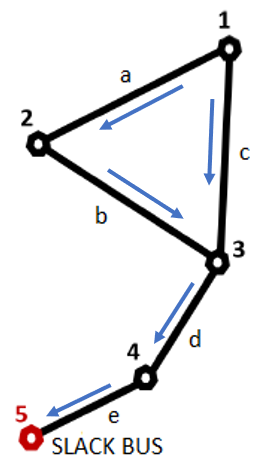

In [41]:
# Create the vectors, linhas são barramentos, colunas são as ligações, para a matriz de incidências
C=np.zeros((nBus,nLines))
nLine_Aux=0

# Determine the Incidence Matrix
for i in range (Y.shape[0]):
    for j in range (i+1,Y.shape[1]):
        if np.absolute(Y[i,j])!=0:
            C[i,nLine_Aux]=1
            C[j,nLine_Aux]=-1
            nLine_Aux=nLine_Aux+1           

#Remove the slack bus from the matrix
Cl=np.delete(C, np.s_[SlackBus-1], axis=0)

print ("The incidence matrix C (nBus,nLines) is:\n",Cl)

The incidence matrix C (nBus,nLines) is:
 [[ 1.  1.  0.  0.  0.]
 [-1.  0.  1.  0.  0.]
 [ 0. -1. -1.  1.  0.]
 [ 0.  0.  0. -1.  1.]]


<b>Definition of Matrix Gij (Diagonal and vector)

In [42]:
# Create the vectors - isto é a matriz de condutâncias, propriedades das linhas a ligar os barramentos
Gv=np.zeros((1,nLines))
Gd=np.zeros((nLines,nLines))
nLine_Aux=0

# Determine the Incidence Matrix
for i in range (Y.shape[0]):
    for j in range (i+1,Y.shape[1]):
        if np.absolute(Y[i,j])!=0:
            Gv[0,nLine_Aux]=-np.real(Y[i,j])          #Information about the lines condutance [Vector]
            Gd[nLine_Aux,nLine_Aux]=-np.real(Y[i,j])  #Information about the lines condutance [Diagonal in matrix]
            nLine_Aux=nLine_Aux+1           


print ("Gij_Diag:\n",Gd)

Gij_Diag:
 [[1. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0.]
 [0. 0. 3. 0. 0.]
 [0. 0. 0. 3. 0.]
 [0. 0. 0. 0. 2.]]


<b>Definition of the Power Losses in two different ways, following equations (13) and (15) of lectures.

- A equação 15 calcula rapidamente as perdas, sem olhar para os ângulos de cada ligação.

- A equação 13 é a que estima realmente as perdas, usando trigonometria - é o Target. 

- Usa-se depois a equação 15 para comparar com os resultados obtidos na equação 13.



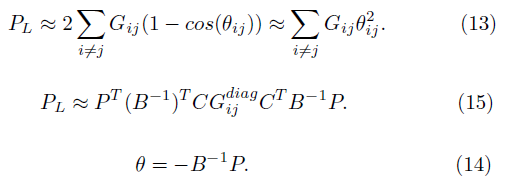

In [43]:
#Matrix creation
teta=np.zeros((nBus-1,time))
grau=np.zeros((nLines,time))
PL=np.zeros((time))
PL2=np.zeros((time))
PT=np.zeros((time))
rLoss=np.zeros((time))

#Losses
alfa=np.dot(np.dot(np.dot(np.dot(np.linalg.inv(B),Cl),Gd),np.transpose(Cl)),np.linalg.inv(B))  #Used in Equation (15)

for m in range (time):
    PL[m]=np.dot(Ptrain[m,:],np.dot(alfa,np.transpose(Ptrain[m,:])))  #Power Losses using equation (15)
    
    teta[:,m]=np.dot(np.linalg.inv(B),np.transpose(Ptrain[m,:])) #Voltage angle (Teta). Equation (14) 

    grau[:,m]=np.dot(np.transpose(Cl),teta[:,m])            #Voltage angle difference (Teta ij)

    PL2[m]=np.dot(2*Gv,1-np.cos(grau[:,m])).item()          #Power Losses using equation (13)

    PT[m]=np.sum([Ptrain[m,:]])                                  #Total Power   

    rLoss[m]=np.divide(PL2[m],PT[m])                        #Power Losses (%)

print ("Total Power consumption:\n",PT ,"\n")    
print ("Power Losses obtained using the Theta:\n",PL2 ,"\n")  
print ("Power Losses obtained without using the Theta:\n",PL ,"\n")  

Total Power consumption:
 [0.6   0.74  2.576 5.168 5.456 5.476 5.012 3.252 3.664 5.388 2.212 1.504
 1.908] 

Power Losses obtained using the Theta:
 [0.0041 0.0067 0.0834 0.3841 0.3083 0.3964 0.1731 0.0827 0.1581 0.3861
 0.0545 0.0294 0.0389] 

Power Losses obtained without using the Theta:
 [0.0041 0.0067 0.0835 0.3859 0.3097 0.3982 0.1738 0.0828 0.1584 0.388
 0.0545 0.0294 0.0389] 



<b>Discovering the loss function

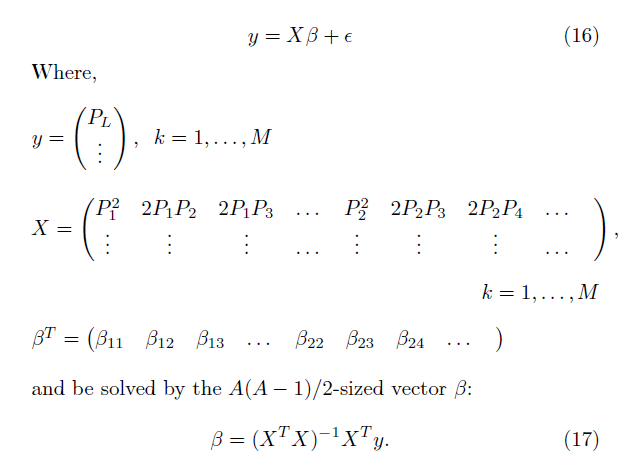

In [44]:
# Este bloco pega nos dados brutos e calcula o P quadratico, portanto a injeção local ao quadrado de cada bus, e as devidas combinações.


Y = PL2.transpose()

def build_injection_matrix(P):
    M, n = P.shape

    X_cols = []
    
    for i in range(n):
        X_cols.append(P[:, i]**2)
        
        for j in range(i + 1, n):
            X_cols.append(2 * P[:, i] * P[:, j])

    return np.column_stack(X_cols)

X = build_injection_matrix(Ptrain)

col_names = ['P1^2', 'P2^2', 'P3^2', 'P4^2', '2P1P2', '2P1P3', '2P1P4', '2P2P3', '2P2P4', '2P3P4']
df_X = pd.DataFrame(X, columns=col_names)
print(df_X)

         P1^2      P2^2      P3^2      P4^2      2P1P2     2P1P3     2P1P4  \
0    0.110224  0.042496  0.055776  0.079680   0.004096  0.010752  0.015360   
1    0.055696  0.077408  0.130272  0.030208   0.026896  0.090528  0.020992   
2    0.050176  0.317184  0.704256  0.032256   0.501264  2.225952  0.101952   
3    0.129600  2.476800  0.855360  0.129600  11.833600  8.173440  1.238400   
4    1.774224  5.796864  1.289376  3.900096   4.734976  2.106368  6.371328   
5    2.298256  9.156640  0.958112  1.891968   9.120400  1.908640  3.768960   
6    0.846400  1.685440  0.743360  5.100480   0.839056  0.740128  5.078304   
7    0.565504  0.962560  0.595584  2.201856   0.409600  0.506880  1.873920   
8    3.341584  2.500704  2.105856  2.105856   0.467856  0.787968  0.787968   
9   12.730624  4.024704  5.908608  3.054208   0.318096  0.933984  0.482784   
10   0.608400  0.555360  1.135680  0.542880   0.126736  0.518336  0.247776   
11   0.732736  0.376640  0.527296  0.205440   0.048400  0.135520

In [45]:
beta = inv(X.transpose() @ X) @ X.transpose() @ Y

print("Length:", len(beta), "-", beta)


Length: 10 - [0.0164 0.0149 0.0121 0.0041 0.0168 0.0134 0.0048 0.0117 0.0061 0.0052]


**Test DataSet - Vamos usar as próximas secções para testar o modelo**
    
Use Loss Function (Beta Coeficients), to compute the losses considering a new Power Consumption dataset - Ptest. 

In [46]:
Xtest = build_injection_matrix(Ptest)

Ytest = Xtest @ beta

cenarios = [f'T. {i+1}' for i in range(len(Ytest))]
df_Ytest = pd.DataFrame(Ytest, index=cenarios, columns=['Perdas Previstas (p.u.)'])

print(df_Ytest)




       Perdas Previstas (p.u.)
T. 1                  0.028058
T. 2                  0.160504
T. 3                  0.496763
T. 4                  0.307836
T. 5                  0.126574
T. 6                  0.272724
T. 7                  0.199565
T. 8                  0.211083
T. 9                  0.586759
T. 10                 0.162089
T. 11                 0.178771
T. 12                 0.095925
T. 13                 0.024199


# Vector initialization - Results Treatment

Comparison between the three methods used:


Table of Absolute Errors
----------------------------------------
        real      alfa      beta
0   0.028105  0.000013  0.000047
1   0.164022  0.000452  0.003517
2   0.507277  0.004246  0.010514
3   0.304182  0.003272  0.003654
4   0.129082  0.000299  0.002508
5   0.274544  0.000908  0.001820
6   0.200447  0.000471  0.000882
7   0.211863  0.000533  0.000780
8   0.586653  0.004089  0.000107
9   0.162701  0.000331  0.000613
10  0.178363  0.000387  0.000409
11  0.096443  0.000123  0.000518
12  0.024343  0.000010  0.000144
----------------------------------------
Average error - alfa:0.1164%
Average error - beta: 0.1962%


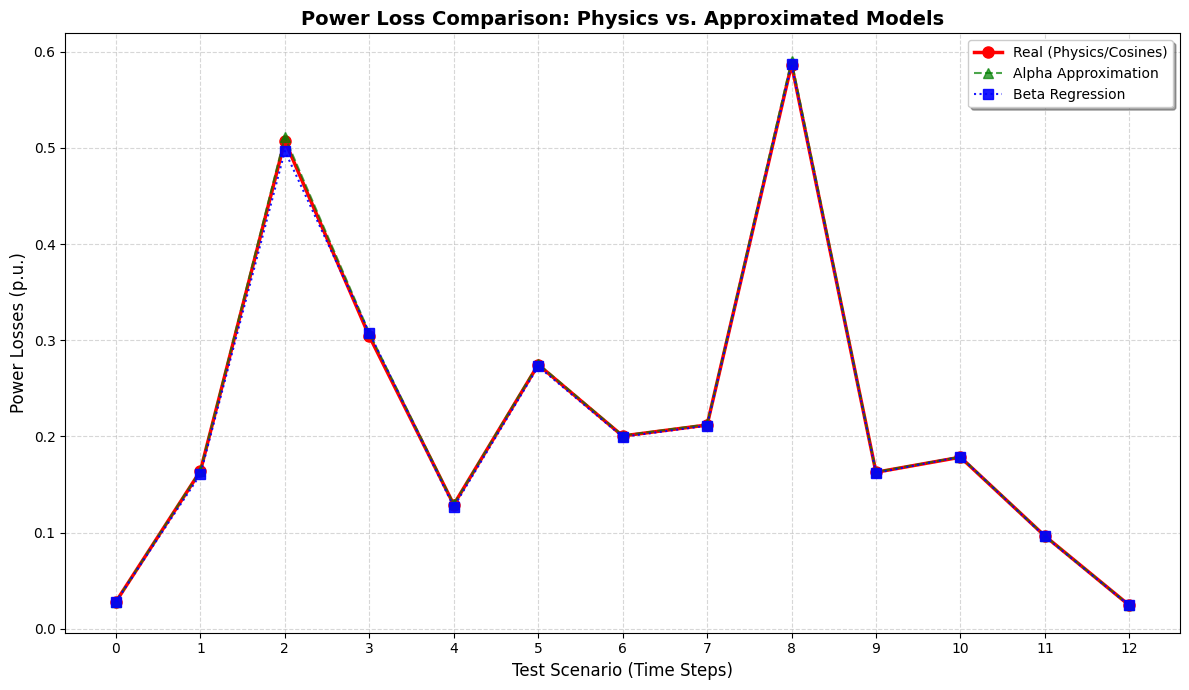

In [47]:
time_test = Ptest.shape[0] # vai-me dar o número de linhas dos inputs do ficheiro excell
teta_test = np.linalg.inv(B) @ Ptest.T
grau_test = Cl.T @ teta_test
Y_Metodo1_Real = np.zeros(time_test) ##  usa leis de kirchoff
for m in range(time_test):
    Y_Metodo1_Real[m] = np.sum(2 * Gv * (1 - np.cos(grau_test[:, m])))


Y_Metodo2_Alfa = np.zeros(time_test) #### leva coeficientes teóricos
for m in range(time_test):
    Y_Metodo2_Alfa[m] = Ptest[m, :] @ alfa @ Ptest[m, :].T


Y_Metodo3_Beta = Xtest @ beta ## usa-se os coeficientes de regressão, vetor coluna

erro_abs_alfa = np.abs(Y_Metodo1_Real - Y_Metodo2_Alfa) ## erros esta linha e a proxuma
erro_abs_beta = np.abs(Y_Metodo1_Real - Y_Metodo3_Beta)

df_erros_detalhado = pd.DataFrame({
    'real': Y_Metodo1_Real,
    'alfa': erro_abs_alfa,
    'beta': erro_abs_beta
})

# 3. Adicionar uma linha com a média (MAE) no final para resumo
print("Table of Absolute Errors")
print("-" * 40)
print(df_erros_detalhado)
print("-" * 40)
print(f"Average error - alfa:{erro_abs_alfa.mean() * 100:.4f}%")
print(f"Average error - beta: {erro_abs_beta.mean() * 100:.4f}%")

plt.figure(figsize=(12, 7))
plt.plot(Y_Metodo1_Real, 'ro-', label='Real (Physics/Cosines)', linewidth=2.5, markersize=8)
plt.plot(Y_Metodo2_Alfa, 'g^--', label='Alpha Approximation', alpha=0.7, markersize=7)
plt.plot(Y_Metodo3_Beta, 'bs:', label='Beta Regression', alpha=0.9, markersize=7)
plt.title('Power Loss Comparison: Physics vs. Approximated Models', fontsize=14, fontweight='bold')
plt.xlabel('Test Scenario (Time Steps)', fontsize=12)
plt.ylabel('Power Losses (p.u.)', fontsize=12)
plt.xticks(range(len(Y_Metodo1_Real)))
plt.legend(loc='best', shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# Challenge
Think about an interesting variation to this problem or a different way to solve and implement it !!!

Some ideas:
- Assume the grid is a LV grid and rewrite (16) assuming that angle differences are negligible (only voltage magnitudes differences are expressive). Assume that in LV grids, Bij << Gij.
- Replace the matrix X, in Equation 16, for:\n
    - i) a matrix X' considering the network structure (only use 2.Pi.Pj when a line connection exists). 
    - ii) reducing the dimensionality of X by considering squared injections (Page 33 in the lectures notes) 
    - iii) reducing the dimensionality of X by summing electrically close bus injections before using them as explanatory variables of losses (Page 33 in the lectures notes)
    - Compare with the proposed method in a larger network






#### 2 proposed challenges
## 

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
ERRO MÉDIO (MAPE) - Neural Network: 15.3882%


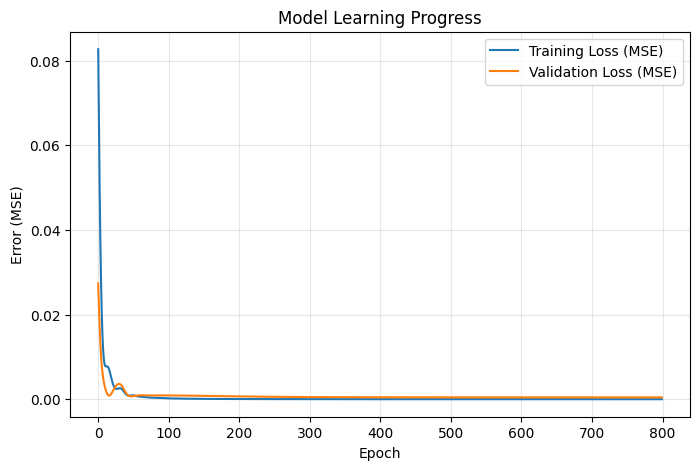

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


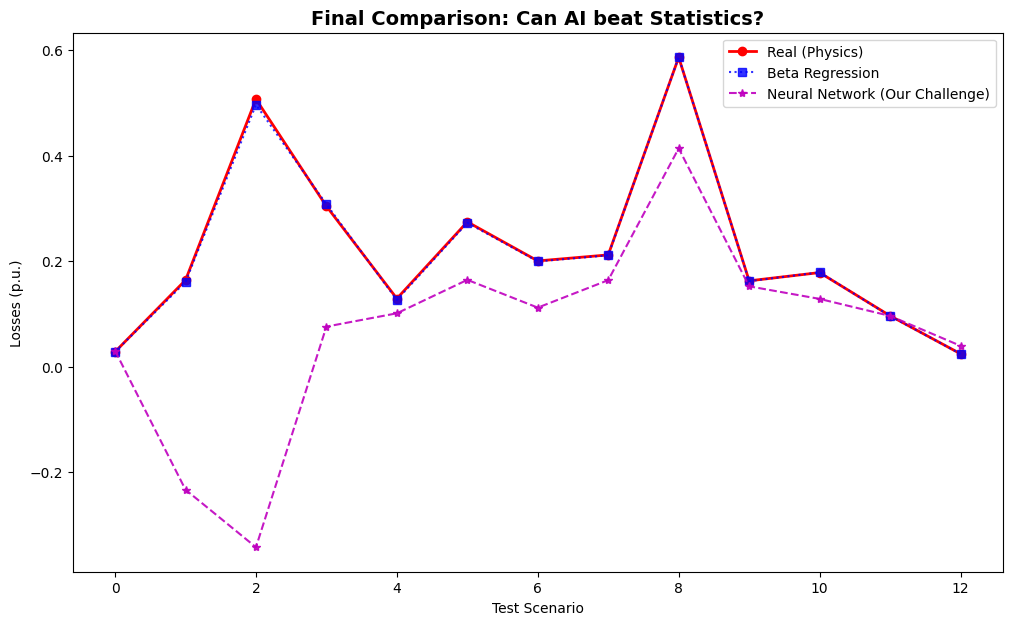

NOVO ERRO MAPE - Neural Network: 15.3882%
You must install pydot (`pip install pydot`) for `plot_model` to work.


FileNotFoundError: [Errno 2] No such file or directory: 'model_structure.png'

In [48]:
"""
Neural networks - primeira via. O que vamos fazer é inves de usar todas as combinações possíveis para fazer a matriz X, vamos apenas dar como 
input os valores de P1,P2,P3,P4 e 


portanto 4 neurónios

duas camadas densas, do género ReLU ACTIVATION - ainda a aprender sobre isto


e um neurónio para output

import sys, tensorflow as tf
print(sys.version)
print("TF:", tf.__version__)
print("Keras via TF:", tf.keras.__version__)
print("Devices:", tf.config.list_physical_devices())
"""



import tensorflow as tf ### biblioteca geral da google
from tensorflow.keras import layers, models #### 
from sklearn.preprocessing import StandardScaler ####


## estes são inputs
X_Train_nn= Ptrain 
### print(f"Formato da Ptrain: {Ptrain.shape}") --- teste só para ver se estava a funcionar como deve ser
X_test_nn= Ptest
## os alvos são as verdas reais que cálculamos com o método físico
y_train_nn = PL2
y_test_nn = Y_Metodo1_Real
scaler = StandardScaler() ## Estamos a normalizar os dados para a rede
X_train_scaled = scaler.fit_transform(X_Train_nn)
X_test_scaled = scaler.transform(X_test_nn)



def build_nn_model():
    model = models.Sequential([
        layers.Input(shape=(4,)),           # 4 entradas
        layers.Dense(32, activation='tanh'), # Camada escondida 1 + Rectified Linear Unit isto ignora os valores negativos e permite a não linearidade
        layers.Dense(16, activation='tanh'),  # Camada escondida 2
        layers.Dense(1)                      # Saída 
    ])
    
    # Optimizer com learning rate mais baixo para maior precisão
    opt = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='mse')
    return model

nn_model = build_nn_model()
nn_model.summary()


history = nn_model.fit(
    X_train_scaled, y_train_nn,
    epochs=800, ## vai ler o dataset x vezes para aprender
    batch_size=64,
    validation_split=0.2,
    verbose=0
)


Y_Metodo4_NN_scaled = nn_model.predict(X_test_scaled)
Y_Metodo4_NN = Y_Metodo4_NN_scaled.flatten()

# Calcular o erro da Rede Neuronal
erro_abs_nn = np.abs(Y_Metodo1_Real - Y_Metodo4_NN)
print(f"ERRO MÉDIO (MAPE) - Neural Network: {erro_abs_nn.mean() * 100:.4f}%")


plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Learning Progress')
plt.xlabel('Epoch')
plt.ylabel('Error (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 1. Previsão final
Y_Metodo4_NN = nn_model.predict(X_test_scaled).flatten()

# 2. Plot
plt.figure(figsize=(12, 7))
plt.plot(Y_Metodo1_Real, 'ro-', label='Real (Physics)', linewidth=2)
plt.plot(Y_Metodo3_Beta, 'bs:', label='Beta Regression', alpha=0.8)
plt.plot(Y_Metodo4_NN, 'm*--', label='Neural Network (Our Challenge)', alpha=0.9)

plt.title('Final Comparison: Can AI beat Statistics?', fontsize=14, fontweight='bold')
plt.xlabel('Test Scenario')
plt.ylabel('Losses (p.u.)')
plt.legend()
plt.show()

# 3. Print do novo erro
erro_nn_final = np.abs(Y_Metodo1_Real - Y_Metodo4_NN).mean() * 100
print(f"NOVO ERRO MAPE - Neural Network: {erro_nn_final:.4f}%")




from tensorflow.keras.utils import plot_model

# Isto cria um esquema visual da tua rede
plot_model(nn_model, to_file='model_structure.png', show_shapes=True, show_layer_names=True)

# Para veres a imagem diretamente no Jupyter Notebook:
from IPython.display import Image
Image(filename='model_structure.png')


###Vamos fazer uma das propostas dos challenges


Redução estrutural, portanto supor que não há ligações entre o bus 1 eo 4 nem entre o 2 e o 3




In [ ]:
### esta é a abordagem (i), vai se tambem fazer a abordagem (i)




### ainda nao olhei para isto

def build_injection_matrix_structural(P):
    n_samples = P.shape[0]
    X_structural = np.zeros((n_samples, 8)) 
    X_structural[:, 0] = P[:, 0]**2 # P1^2
    X_structural[:, 1] = P[:, 1]**2 # P2^2
    X_structural[:, 2] = P[:, 2]**2 # P3^2
    X_structural[:, 3] = P[:, 3]**2 # P4^2
    X_structural[:, 4] = 2 * P[:, 0] * P[:, 1] # Ligação 1-2
    X_structural[:, 5] = 2 * P[:, 0] * P[:, 2] # Ligação 1-3
    X_structural[:, 6] = 2 * P[:, 1] * P[:, 3] # Ligação 2-3
    X_structural[:, 7] = 2 * P[:, 2] * P[:, 3] # Ligação 3-4
    
    return X_structural

X_train_red = build_injection_matrix_structural(Ptrain)
X_test_red = build_injection_matrix_structural(Ptest)

Beta_red = np.linalg.inv(X_train_red.T @ X_train_red) @ X_train_red.T @ PL2
Y_Metodo3_Beta_Red = X_test_red @ Beta_red

erro_abs_beta_red = np.abs(Y_Metodo1_Real - Y_Metodo3_Beta_Red)
print(f"MAPE - Beta Estrutural (Reduzido): {erro_abs_beta_red.mean() * 100:.8f}%")




MAPE - Beta Estrutural (Reduzido): 3.87410205%


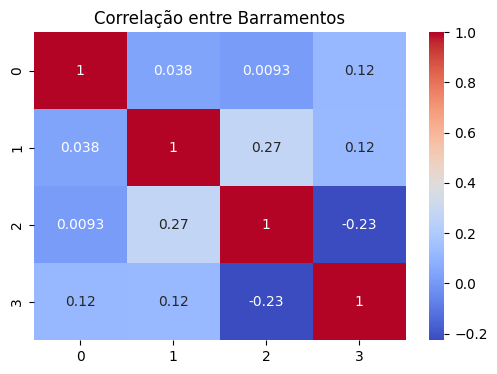

MAPE - Modelo Original (10 vars): 0.827038%
MAPE - Modelo Agrupado (6 vars): 4.972759%


In [52]:
### abordagem (3)


"""
Este conceito baseia-se na ideia de que, numa rede elétrica, 
barramentos que estão muito próximos ou que têm comportamentos 
de carga idênticos podem ser tratados como um único bloco funcional.
 Em vez de tentares prever as perdas usando quatro variáveis independentes
 ($P_1, P_2, P_3, P_4$), tu agrupas (somas) as injeções de barramentos 
 "eletricamente próximos" antes de as passares para o modelo. 
 Isto simplifica drasticamente a matemática e reduz o risco de o modelo
   "se perder" em detalhes irrelevantes, focando-se apenas nos grandes
     fluxos de energia que realmente causam o grosso das perdas na rede.


     

É CHAT, É SO PARA PERCEBER O QUE SE ESTA AQUI A PASSAR
"""




import seaborn as sns

# Ver quais barramentos se comportam de forma igual
plt.figure(figsize=(6,4))
sns.heatmap(pd.DataFrame(Ptrain).corr(), annot=True, cmap='coolwarm')
plt.title("Correlação entre Barramentos")
plt.show()


def build_grouped_matrix(P):
    n_samples = P.shape[0]
    # Agrupamos P1 e P2 numa única variável (Soma)
    P_grouped = np.zeros((n_samples, 3))
    P_grouped[:, 0] = P[:, 0] + P[:, 1] # Novo P_alpha (P1 + P2)
    P_grouped[:, 1] = P[:, 2]           # P3 original
    P_grouped[:, 2] = P[:, 3]           # P4 original
    
    # Criamos a matriz X para 3 variáveis (3 quadrados + 3 interações = 6 colunas)
    X_grp = np.zeros((n_samples, 6))
    
    # Quadrados
    X_grp[:, 0] = P_grouped[:, 0]**2
    X_grp[:, 1] = P_grouped[:, 1]**2
    X_grp[:, 2] = P_grouped[:, 2]**2
    
    # Interações (2*Pi*Pj)
    X_grp[:, 3] = 2 * P_grouped[:, 0] * P_grouped[:, 1]
    X_grp[:, 4] = 2 * P_grouped[:, 0] * P_grouped[:, 2]
    X_grp[:, 5] = 2 * P_grouped[:, 1] * P_grouped[:, 2]
    
    return X_grp

# Preparar dados
X_train_grp = build_grouped_matrix(Ptrain)
X_test_grp = build_grouped_matrix(Ptest)

# Calcular Beta por Mínimos Quadrados
Beta_grp = np.linalg.inv(X_train_grp.T @ X_train_grp) @ X_train_grp.T @ PL2
mape_beta_original = np.mean(np.abs((Y_Metodo1_Real - Y_Metodo3_Beta) / Y_Metodo1_Real)) * 100

# Previsão e Erro
Y_pred_grp = X_test_grp @ Beta_grp
mape_grp = np.mean(np.abs((Y_Metodo1_Real - Y_pred_grp) / Y_Metodo1_Real)) * 100

print(f"MAPE - Modelo Original (10 vars): {mape_beta_original:.6f}%")
print(f"MAPE - Modelo Agrupado (6 vars): {mape_grp:.6f}%")




In [ ]:
# Exemplo rápido (precisarias de instalar: pip install pandapower)
import pandapower as pp
import pandapower.networks as nw

# Carregar uma rede standard de 30 barramentos
net = nw.case30()

# Correr o fluxo de carga
pp.runpp(net)

# As perdas totais estariam aqui:
perdas = net.res_line.pl_mw.sum() + net.res_trafo.pl_mw.sum()



def build_huge_x(P):
    n_s, n_b = P.shape
    # Quadrados (30) + Interações (30*29/2 = 435) = 465 colunas
    cols = n_b + (n_b * (n_b - 1) // 2)
    X = np.zeros((n_s, cols))
    
    # Preencher quadrados
    X[:, :n_b] = P**2
    
    # Preencher interações (isto vai demorar muito mais num PC normal)
    idx = n_b
    for i in range(n_b):
        for j in range(i+1, n_b):
            X[:, idx] = 2 * P[:, i] * P[:, j]
            idx += 1
    return X

X_huge = build_huge_x(P_large)
print(f"A tua matriz X agora tem {X_huge.shape[1]} colunas!")

from tensorflow.keras import models, layers

# A arquitetura quase não muda, só o Input(shape=(30,))
nn_large = models.Sequential([
    layers.Input(shape=(30,)), 
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

nn_large.compile(optimizer='adam', loss='mse')
nn_large.fit(P_large, Y_large, epochs=100, batch_size=32, verbose=1)

# 1. Criar dados de teste novos (que a rede nunca viu)
P_test_large, Y_test_real = generate_large_network_data(n_bus=30, n_samples=200)

# 2. Fazer a previsão com a Rede Neuronal
Y_pred_nn_large = nn_large.predict(P_test_large).flatten()

# 3. Calcular o Erro Médio Percentual Absoluto (MAPE)
# Usamos a fórmula real do MAPE: mean( |(Real - Previsto) / Real| ) * 100
mape_large = np.mean(np.abs((Y_test_real - Y_pred_nn_large) / Y_test_real)) * 100

print(f"\n--- RESULTADOS REDE DE 30 BARRAMENTOS ---")
print(f"Erro Médio (MAPE): {mape_large:.4f}%")


Dataset gerado: 1000 cenários com 30 barramentos.
A tua matriz X agora tem 465 colunas!
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0380   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0150 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0102 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0076 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0060 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0050 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0042 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0036 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0031 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0027 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0025 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0023 
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0020 
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━